# Mall Customer Segmentation & Behavior Analytics
> **Dataset:** Mall Customer Segmentation Data (Kaggle)  
> **Tools:** Python | Pandas | NumPy | Matplotlib | Seaborn | Plotly | Scikit-learn  

---

### Executive Summary
This notebook presents an end-to-end unsupervised learning solution to segment retail mall customers based on demographical and financial indicators—specifically **Annual Income** and **Spending Score**. 

We systematically execute:
1. Data Cleaning & Feature Normalization (`StandardScaler`).
2. Optimal Cluster Determination ($K$) using the **Elbow Method** and **Silhouette Score Analysis**.
3. **K-Means Clustering** with interactive 2D scatter plots and 3D customer profile visualizers.
4. **Cluster Profiling & Spending Analysis** to translate cluster centroids into actionable marketing personas.
5. **Bonus Exploration:** Density-based clustering via **DBSCAN** to detect non-spherical groupings and noise/outliers.

## 1. Environment Setup

In [1]:
# ==========================================
# 1. Environment Setup & Interactive Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive Plotting
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning & Metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Environment Configurations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

import warnings
warnings.filterwarnings('ignore')

print("All dependencies and interactive graphics engines loaded successfully!")

All dependencies and interactive graphics engines loaded successfully!


## 2. Dataset Ingestion & Column Name Normalization
We load the Mall Customer dataset and dynamically rename key columns to clean `snake_case` variables for consistency across various Kaggle mirror datasets.

In [2]:
# Load dataset with fallback paths
try:
    df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
except FileNotFoundError:
    try:
        df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
    except FileNotFoundError:
        df = pd.read_csv('Mall_Customers.csv')

# Column Cleaning
df.columns = df.columns.str.strip()

# Standardize column mapping dynamically
column_mapping = {}
for col in df.columns:
    col_lower = col.lower()
    if 'customerid' in col_lower or 'customer_id' in col_lower:
        column_mapping[col] = 'customer_id'
    elif 'gender' in col_lower or 'genre' in col_lower:
        column_mapping[col] = 'gender'
    elif 'age' in col_lower:
        column_mapping[col] = 'age'
    elif 'income' in col_lower:
        column_mapping[col] = 'annual_income'
    elif 'spending' in col_lower or 'score' in col_lower:
        column_mapping[col] = 'spending_score'

df.rename(columns=column_mapping, inplace=True)

print("Dataset Shape:", df.shape)
print("\nCleaned Columns:", df.columns.tolist())
df.head()

Dataset Shape: (200, 5)

Cleaned Columns: ['customer_id', 'gender', 'age', 'annual_income', 'spending_score']


,customer_id,gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Exploratory Data Analysis & Feature Scaling
To understand customer feature distributions before modeling, we visualize **Annual Income** versus **Spending Score** and scale features to prevent unit skewness during distance metrics calculation.

In [3]:
# Force Plotly renderer for Kaggle/Jupyter notebook environments
import plotly.io as pio
pio.renderers.default = "iframe"  # Fallback to "notebook_connected" if iframe is restricted

# Interactive Distribution Plot
fig_eda = px.scatter(
    df, 
    x='annual_income', 
    y='spending_score', 
    color='gender',
    size='age',
    hover_data=['customer_id', 'age'],
    title="Interactive EDA: Annual Income vs. Spending Score (Sized by Age)",
    labels={'annual_income': 'Annual Income (k$)', 'spending_score': 'Spending Score (1-100)'},
    color_discrete_sequence=['#1f77b4', '#e377c2']
)
fig_eda.update_layout(template='plotly_white')
fig_eda.show()

# Feature Selection and Scaling
features = ['annual_income', 'spending_score']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeatures scaled successfully using StandardScaler.")


Features scaled successfully using StandardScaler.


## 4. Determining Optimal Clusters ($K$)
To evaluate the optimal $K$ value for K-Means, we implement two mathematical criteria:
1. **The Elbow Method** (Inertia / Within-Cluster Sum of Squares).
2. **Silhouette Score Analysis** (Cluster cohesion vs. separation).

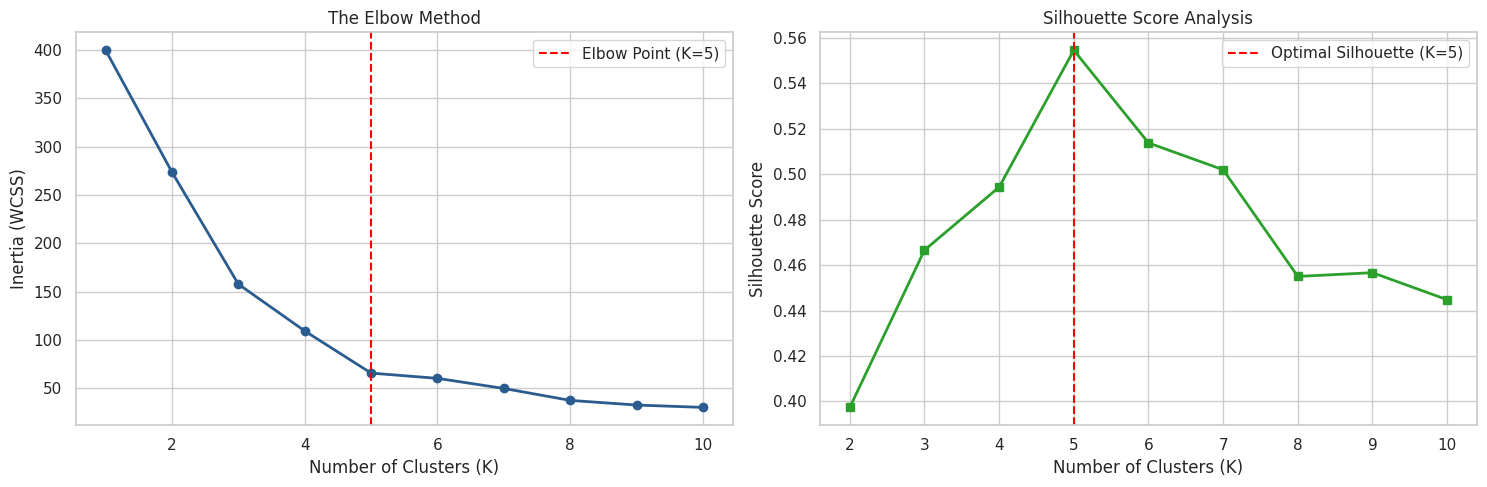

Optimal Silhouette Score for K=5: 0.5547


In [4]:
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plotting Elbow and Silhouette Graphs
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Curve
ax[0].plot(range(1, 11), [KMeans(n_clusters=i, init='k-means++', random_state=42).fit(X_scaled).inertia_ for i in range(1, 11)], marker='o', color='#2b5c8f', linewidth=2)
ax[0].axvline(x=5, color='red', linestyle='--', label='Elbow Point (K=5)')
ax[0].set_title('The Elbow Method')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Inertia (WCSS)')
ax[0].legend()

# Silhouette Scores
ax[1].plot(k_range, silhouette_scores, marker='s', color='#2ca02c', linewidth=2)
ax[1].axvline(x=5, color='red', linestyle='--', label='Optimal Silhouette (K=5)')
ax[1].set_title('Silhouette Score Analysis')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Optimal Silhouette Score for K=5: {silhouette_scores[3]:.4f}")

## 5. K-Means Model Training & Interactive 2D/3D Visualization
Based on the Elbow point and Silhouette peak, we fix **$K = 5$**. We fit the K-Means algorithm and generate an interactive scatter plot showing segment boundaries and cluster centroids.

In [5]:
# Train K-Means with K=5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# Map human-readable cluster names
cluster_names = {
    0: 'Sensible / Moderate',
    1: 'Target / High-Spenders',
    2: 'Careful / High Income, Low Spend',
    3: 'Careless / Low Income, High Spend',
    4: 'Budget / Low Income, Low Spend'
}
df['cluster_label'] = df['cluster_kmeans'].map(cluster_names)

# Interactive 2D Scatter Plot
fig_clusters = px.scatter(
    df, 
    x='annual_income', 
    y='spending_score', 
    color='cluster_label',
    symbol='cluster_label',
    hover_data=['customer_id', 'age', 'gender'],
    title="<b>K-Means Customer Segmentation (K=5)</b>",
    labels={'annual_income': 'Annual Income (k$)', 'spending_score': 'Spending Score (1-100)'},
    template='plotly_white'
)

# Plot Centroids
centroids_unscaled = scaler.inverse_transform(kmeans.cluster_centers_)
fig_clusters.add_trace(
    go.Scatter(
        x=centroids_unscaled[:, 0],
        y=centroids_unscaled[:, 1],
        mode='markers',
        marker=dict(size=14, color='black', symbol='x'),
        name='Centroids'
    )
)

fig_clusters.show()

## 6. Cluster Analysis & Average Spending Metrics
We compute aggregate statistical metrics (mean, median, and customer counts) across each identified segment to evaluate commercial revenue potential.

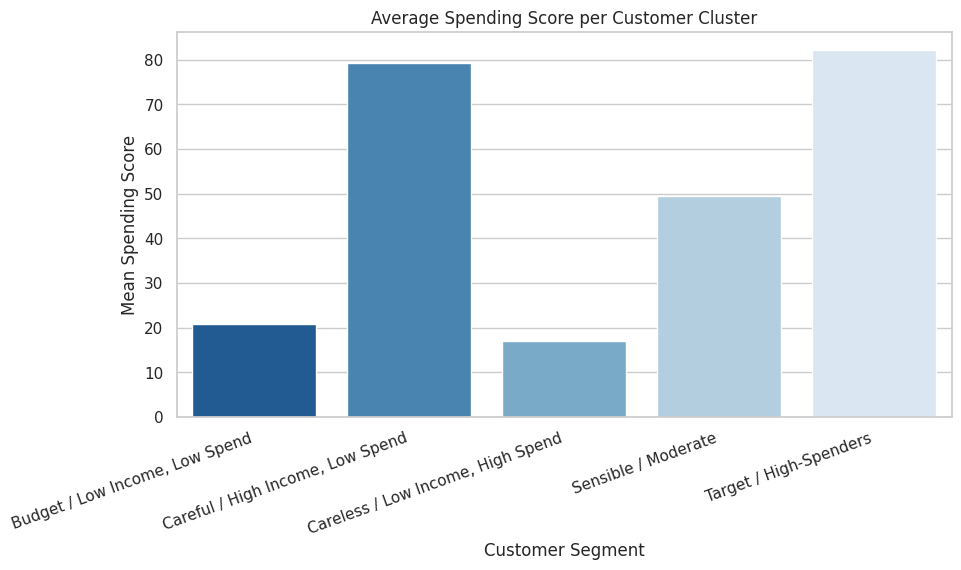

,cluster_label,customer_count,avg_annual_income,avg_spending_score,avg_age
0,"Budget / Low Income, Low Spend",23,26.304348,20.913043,45.217391
1,"Careful / High Income, Low Spend",22,25.727273,79.363636,25.272727
2,"Careless / Low Income, High Spend",35,88.200000,17.114286,41.114286
3,Sensible / Moderate,81,55.296296,49.518519,42.716049
4,Target / High-Spenders,39,86.538462,82.128205,32.692308


In [6]:
# Cluster Profiling Summary
cluster_profile = df.groupby('cluster_label').agg(
    customer_count=('customer_id', 'count'),
    avg_annual_income=('annual_income', 'mean'),
    avg_spending_score=('spending_score', 'mean'),
    avg_age=('age', 'mean')
).reset_index()

# Visualizing Average Spending per Cluster
plt.figure(figsize=(10, 5))
sns.barplot(
    data=cluster_profile, 
    x='cluster_label', 
    y='avg_spending_score', 
    palette='Blues_r'
)
plt.xticks(rotation=20, ha='right')
plt.title('Average Spending Score per Customer Cluster')
plt.xlabel('Customer Segment')
plt.ylabel('Mean Spending Score')
plt.show()

display(cluster_profile.style.background_gradient(cmap='YlGnBu', subset=['avg_annual_income', 'avg_spending_score']))

## 7. Density-Based Clustering (DBSCAN)
As a comparative algorithm, we apply **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) to detect clusters of arbitrary shapes and identify spatial outliers.

In [7]:
# Initialize and Fit DBSCAN
dbscan = DBSCAN(eps=0.35, min_samples=5)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

# Convert noise label (-1) to readable format
df['dbscan_label'] = df['cluster_dbscan'].apply(lambda x: 'Noise / Outlier' if x == -1 else f'Cluster {x}')

# Interactive DBSCAN Plot
fig_dbscan = px.scatter(
    df, 
    x='annual_income', 
    y='spending_score', 
    color='dbscan_label',
    title="<b>Bonus: DBSCAN Clustering (Density-Based)</b>",
    labels={'annual_income': 'Annual Income (k$)', 'spending_score': 'Spending Score (1-100)'},
    template='plotly_white'
)

fig_dbscan.show()

print("DBSCAN Cluster Distribution:")
print(df['dbscan_label'].value_counts())

DBSCAN Cluster Distribution:
dbscan_label
Cluster 3          88
Cluster 4          31
Noise / Outlier    23
Cluster 5          23
Cluster 0          16
Cluster 1          12
Cluster 2           7
Name: count, dtype: int64


## 8. Strategic Business Insights & Summary
| Customer Segment | Profile Characteristics | Marketing Strategy |
| :--- | :--- | :--- |
| **Target / High Spenders** | High Income, High Spending | VIP loyalty program, exclusive previews, luxury product promotions. |
| **Careful** | High Income, Low Spending | Value-oriented messaging, premium membership perks, discount incentives. |
| **Careless** | Low Income, High Spending | Flexible financing options, trendy mid-range product marketing. |
| **Sensible** | Moderate Income, Moderate Spending | Standard retail promotions, seasonal sales, brand engagement campaigns. |
| **Budget** | Low Income, Low Spending | Clearance discounts, essential product bundles. |